In [26]:
# NEW CODE
import numpy as np
import importlib
import pandas as pd
import os
import random
import joblib
from pythermalcomfort.models import pmv_ppd_iso
import torch
import Hvac_predict_script

importlib.reload(Hvac_predict_script)
from Hvac_predict_script import predict_Tin_sequence_full, LSTMWithFuture, CNNLSTMWithFuture

folder_path = 'datasets/retrofit/resampled'

dfs = []

for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
       
        df['timestamp'] = pd.to_datetime(df['timestamps'])
        
        df.drop(columns=['timestamps'], inplace=True)
        df.set_index('timestamp', inplace=True)
        df.sort_index(inplace=True)
        dfs.append(df)

test_start = pd.Timestamp('2023-01-22')
test_end = pd.Timestamp('2023-01-29')

df = dfs[0].copy()
relevant_cols = ['total_energy', 'hvac_energy', 'Tin', 'Tout', 'RH']
df_relevant = df.copy()

nan_at_end = df_relevant[relevant_cols].iloc[::-1].isna().cumprod().iloc[::-1].astype(bool)
rows_to_drop = nan_at_end.any(axis=1)
df_cleaned = df_relevant[~rows_to_drop].copy()
sensor_nan_rows = df_cleaned[['Tin', 'Tout', 'RH']].isna().any(axis=1)
df_cleaned.loc[
    (df_cleaned['total_energy'] == 0.0) & sensor_nan_rows,
    'total_energy'
] = np.nan
df_cleaned[['total_energy', 'Tin', 'Tout', 'RH']] = df_cleaned[
    ['total_energy', 'Tin', 'Tout', 'RH']
].interpolate(method='linear', limit_direction='both')
# df.drop(index=df[df['total_energy'] == 0.0].index, inplace=True)
df = df_cleaned.copy()

df['T_diff'] = (df['Tout'] - df['Tin']).bfill()
df['hour'] = df.index.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month'] = df.index.month

# results.append({
#         'timestamp': df_test.index[idx],
#         'Tin_pred': Tin_pred,
#         'Tin_true': row['Tin'],
#         'hvac_mode': hvac_mode,
#         'Tin_target': row['Tin_target'],
#         'RH_pred': RH_pred,
#         'RH_true': row['RH'],
# })
tin_model = LSTMWithFuture(input_size=3, hidden_size=128, num_layers=2)
tin_model.load_state_dict(torch.load('best_model_tin.pt'))
rh_model = CNNLSTMWithFuture(input_size=7, hidden_size=128, num_layers=2)
rh_model.load_state_dict(torch.load('best_model_rh.pt'))

scaler_tin = joblib.load('scaler_tin.pkl')
scaler_rh = joblib.load('scaler_rh.pkl')

df['Tin_target']  = df['Tin'].shift(-1).dropna()          
df['is_test'] = (df.index >= test_start) & (df.index <= test_end)
df['RH_target'] = df['RH'].shift(-1)

df['hvac_mode'] = 0 
on_mask = df['hvac_energy'] > 0
nonzero_power = df.loc[on_mask, 'hvac_energy']
bins = pd.qcut(nonzero_power, q=2, labels=[1, 2])
df.loc[on_mask, 'hvac_mode'] = bins.astype(int).values

df_test = df[df['is_test']].copy()
df_encoded_test = df_test.copy()
df_encoded_test = df_encoded_test.join(pd.get_dummies(df_test['hvac_mode'], prefix='hvac'))

rf_model = joblib.load('best_model_rf.pkl')

import random

def generate_schedule():
    return [random.choice([0, 1, 2]) for _ in range(96)]

def calculate_overall_comfort(list_tin, list_rh):
    ppd_values = []
    for tin, rh in zip(list_tin, list_rh):
        comfort = pmv_ppd_iso(
            tdb=tin,
            tr=tin,     
            vr=0.1,     
            rh=rh,
            met=1.1,    
            clo=1.0     
        )
        if comfort['ppd'] is None:
            print(tin)
            ppd_values.append(75)  
        else:
            ppd_values.append(comfort['ppd'])  
    return ppd_values  

def evaluate_schedule(schedule = None):
    if schedule is None:
        schedule = generate_schedule()

    results = predict_Tin_sequence_full(        
        df_test=df_encoded_test,  
        window_start_idx=10,       
        lstm_model=tin_model,     
        rf_model=rf_model,  
        tin_scaler=scaler_tin,   
        rh_model=rh_model,        
        rh_scaler=scaler_rh,     
        n_steps=96,
        hvac_schedule=schedule             
    )
    
    tin_pred = results['Tin_pred'].values
    rh_pred = results['RH_pred'].values
    ppd_list = calculate_overall_comfort(tin_pred, rh_pred)  
    
    avg_ppd = 100 - np.mean(ppd_list)
    print(f"Average comfort percentage: {avg_ppd:.2f}")
    # switches = count_switches(schedule)
    # if switches > 20:
    #     avg_ppd += 0.5  # soft penalty
    
    # return avg_ppd

def count_switches(schedule):
    return sum(1 for i in range(1, len(schedule)) if schedule[i] != schedule[i-1])

evaluate_schedule()


Average comfort percentage: 86.53


In [27]:
import pygad
import numpy as np

hvac_choices = [0, 1, 2]

def fitness_func(ga_instance, solution, solution_idx):
    schedule = [int(x) for x in solution]  
    results = predict_Tin_sequence_full(
        df_test=df_encoded_test,
        window_start_idx=100,
        lstm_model=tin_model,
        rf_model=rf_model,
        tin_scaler=scaler_tin,
        rh_model=rh_model,
        rh_scaler=scaler_rh,
        n_steps=96,
        hvac_schedule=schedule
    )
    tin_pred = results['Tin_pred'].values
    rh_pred = results['RH_pred'].values
    list_rh = df_test['RH'].iloc[10:10 + 96].tolist()

    ppd_list = calculate_overall_comfort(tin_pred, rh_pred)
    avg_ppd = np.nanmean(ppd_list)
    
    return 100 - avg_ppd  

gene_space = hvac_choices
num_genes = 96

ga_instance = pygad.GA(
    num_generations=15,
    num_parents_mating=10,
    fitness_func=fitness_func,
    sol_per_pop=20,
    num_genes=num_genes,
    gene_space=gene_space,
    parent_selection_type="tournament",
    keep_parents=4,
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=15,
    stop_criteria=["saturate_30"]
)

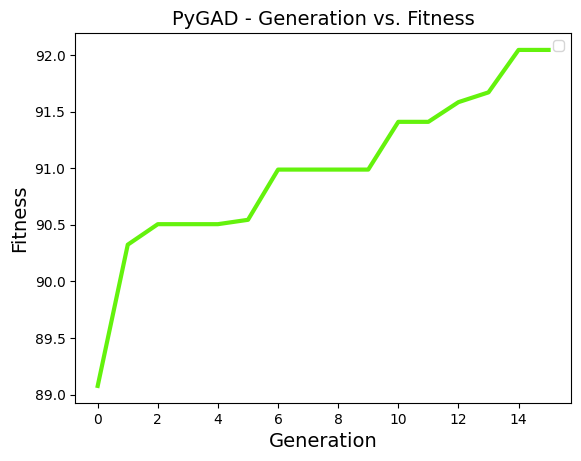

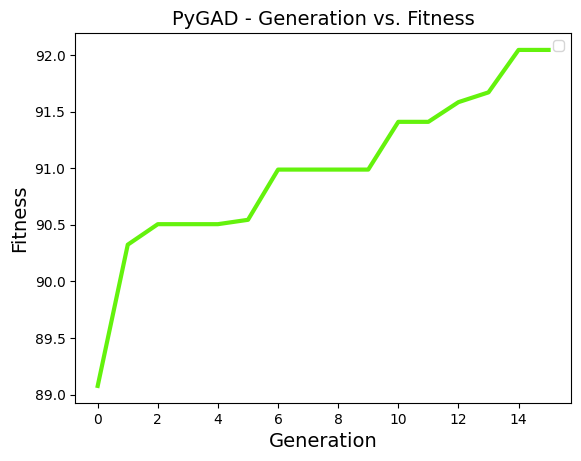

In [8]:
ga_instance.run()
ga_instance.plot_fitness()

In [9]:
solution, fitness, _ = ga_instance.best_solution()
best_schedule = [int(x) for x in solution]
print("Best schedule:", best_schedule)
print("Best avg comfort score (100 - PPD):", fitness)

Best schedule: [1, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 1, 0, 2, 0, 2, 1, 1, 0, 0, 2, 1, 2, 2, 1, 0, 2, 1, 2, 1, 1, 2, 2, 1, 2, 2, 1, 0, 1, 1, 2, 0, 1, 2, 0, 1, 1, 2, 1, 2, 0, 1, 1, 0, 0, 1, 0, 2, 1, 1, 2, 2, 1, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 2, 2, 0, 1, 2, 1, 2, 2, 0, 1, 0, 1, 0, 0, 1, 2, 1, 1, 2, 1, 0, 0]
Best avg comfort score (100 - PPD): 91.803125


In [ ]:
def evaluate_ground_truth_comfort(df_test, window_start_idx):
    list_tin = df_test['Tin'].iloc[window_start_idx:window_start_idx + 96].tolist()
    list_rh = df_test['RH'].iloc[window_start_idx:window_start_idx + 96].tolist()

    ppd_list = calculate_overall_comfort(list_tin, list_rh)
    avg_ppd = np.nanmean(ppd_list)

    comfort_score = 100 - avg_ppd
    print("Ground Truth Comfort Score (100 - avg PPD):", round(comfort_score, 2))

    return comfort_score

evaluate_ground_truth_comfort(df_encoded_test, window_start_idx=10)


Ground Truth Comfort Score (100 - avg PPD): 77.54


np.float64(77.54062499999999)

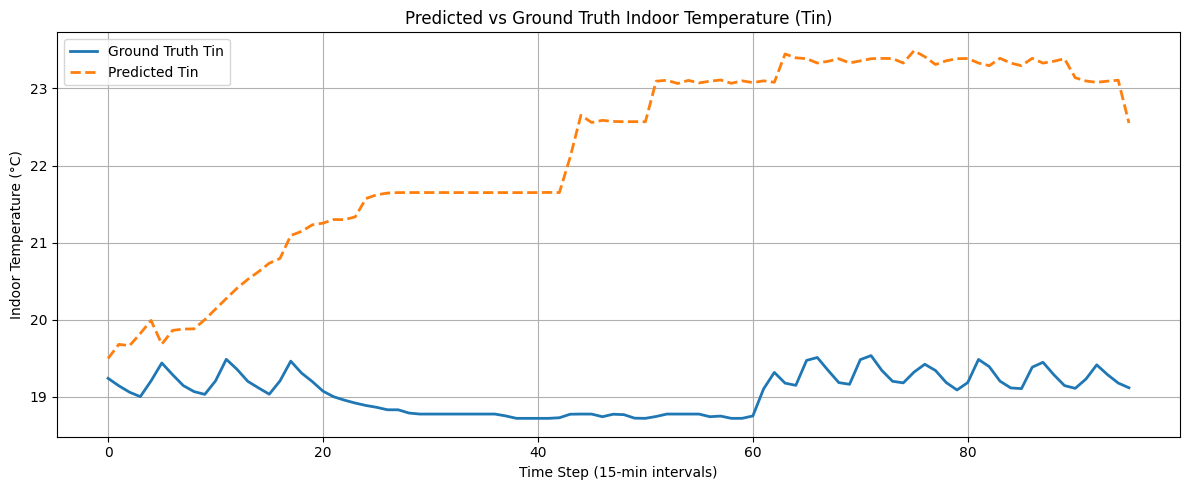

Ground Truth Comfort Score (100 - avg PPD): 77.87


In [ ]:
import matplotlib.pyplot as plt
# print(test)
results = predict_Tin_sequence_full(        
    df_test=df_encoded_test,  
    window_start_idx=10,       
    lstm_model=tin_model,     
    rf_model=rf_model,  
    tin_scaler=scaler_tin,   
    rh_model=rh_model,        
    rh_scaler=scaler_rh,     
    n_steps=96,
    hvac_schedule=best_schedule             
)

def plot_tin_prediction_vs_ground_truth(results):
    predicted_tin = results['Tin_pred'].values

    ground_truth_tin = results['Tin_target'].values

    time_steps = range(96)

    plt.figure(figsize=(12, 5))
    plt.plot(time_steps, ground_truth_tin, label='Ground Truth Tin', linewidth=2)
    plt.plot(time_steps, predicted_tin, label='Predicted Tin', linestyle='--', linewidth=2)
    plt.xlabel("Time Step (15-min intervals)")
    plt.ylabel("Indoor Temperature (°C)")
    plt.title("Predicted vs Ground Truth Indoor Temperature (Tin)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_tin_prediction_vs_ground_truth(results)
list_tin = results['Tin_target'].values
list_rh = results['RH_true'].values
ppd_list = calculate_overall_comfort(list_tin, list_rh)
avg_ppd = np.nanmean(ppd_list)

comfort_score = 100 - avg_ppd
print("Ground Truth Comfort Score (100 - avg PPD):", round(comfort_score, 2))



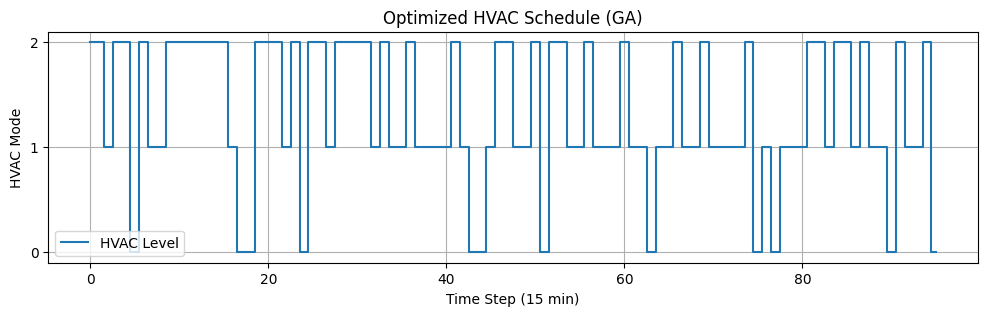

In [7]:
plt.figure(figsize=(12, 3))
plt.step(range(96), best_schedule, where='mid', label='HVAC Level')
plt.yticks([0, 1, 2])
plt.xlabel("Time Step (15 min)")
plt.ylabel("HVAC Mode")
plt.title("Optimized HVAC Schedule (GA)")
plt.grid(True)
plt.legend()
plt.show()

In [28]:
from pyomo.environ import ConcreteModel, Var, Objective, Constraint, SolverFactory, RangeSet, Binary, value, maximize
import numpy as np

pv_data = pd.read_csv('datasets/pv_data/shifted_pv_data.csv')

start_time = df_encoded_test.index[100]
end_time = start_time + pd.Timedelta(minutes=15 * 95)

pv_data['timestamps'] = pd.to_datetime(pv_data["timestamps"])  # just in case
pv_window = pv_data[
    (pv_data["timestamps"] >= start_time) &
    (pv_data["timestamps"] <= end_time)
].copy()


pv_forecast = (pv_window["total_energy"] > 0.05).astype(int).tolist()
time_steps = 96
lambda_comfort = 0.0  
# pv_forecast = np.random.choice([0, 1], size=time_steps).tolist()  

model = ConcreteModel()
model.T = RangeSet(0, time_steps - 1)
model.mode_0 = Var(model.T, domain=Binary)
model.mode_1 = Var(model.T, domain=Binary)
model.mode_2 = Var(model.T, domain=Binary)

def mode_constraint_rule(model, t):
    return model.mode_0[t] + model.mode_1[t] + model.mode_2[t] == 1
model.mode_constraint = Constraint(model.T, rule=mode_constraint_rule)

def objective_rule(model):
       return sum(
        (model.mode_1[t] + model.mode_2[t]) * (pv_forecast[t] - 0.25 * (1 - pv_forecast[t]))
        for t in model.T
    )


# model.objective = Objective(rule=objective_rule, sense=maximize)

# solver = SolverFactory('cbc')
# results = solver.solve(model, tee=False)

# hvac_schedule = []
# for t in model.T:
#     if value(model.mode_2[t]) == 1:
#         hvac_schedule.append(2)
#     elif value(model.mode_1[t]) == 1:
#         hvac_schedule.append(1)
#     else:
#         hvac_schedule.append(0)

# results = predict_Tin_sequence_full(
#     df_test=df_encoded_test,
#     window_start_idx=100,
#     lstm_model=tin_model,
#     rf_model=rf_model,
#     tin_scaler=scaler_tin,
#     rh_model=rh_model,
#     rh_scaler=scaler_rh,
#     n_steps=96,
#     hvac_schedule=hvac_schedule
# )
# Tin_pred = results['Tin_pred'].values
# RH_pred = results['RH_pred'].values
# ppd_list = calculate_overall_comfort(Tin_pred, RH_pred)
# avg_ppd = np.nanmean(ppd_list)
# avg_comfort = 100 - avg_ppd  


comfort_threshold = 80
min_on_steps = 0
max_iterations = 10

for attempt in range(max_iterations):
    model.objective = Objective(rule=objective_rule, sense=maximize)

    solver = SolverFactory('cbc')
    results = solver.solve(model, tee=False)

    hvac_schedule = []
    for t in model.T:
        if value(model.mode_2[t]) == 1:
            hvac_schedule.append(2)
        elif value(model.mode_1[t]) == 1:
            hvac_schedule.append(1)
        else:
            hvac_schedule.append(0)

    results = predict_Tin_sequence_full(
        df_test=df_encoded_test,
        window_start_idx=100,
        lstm_model=tin_model,
        rf_model=rf_model,
        tin_scaler=scaler_tin,
        rh_model=rh_model,
        rh_scaler=scaler_rh,
        n_steps=96,
        hvac_schedule=hvac_schedule
    )
    Tin_pred = results['Tin_pred'].values
    RH_pred = results['RH_pred'].values
    ppd_list = calculate_overall_comfort(Tin_pred, RH_pred)
    comfort_list = [100 - ppd for ppd in ppd_list]

    all_above = all(c >= comfort_threshold for c in comfort_list)

    if all_above:
        print(f"✅ Schedule OK at attempt {attempt+1} — all comfort ≥ {comfort_threshold}%")
        break
    else:
        print(f"❌ Schedule rejected at attempt {attempt+1} — some comfort < {comfort_threshold}%")
        min_on_steps += 4  

# if avg_comfort >= 80:
#     print(f"✅ Optimal schedule found with average comfort: {avg_comfort:.2f}%")
# else:
#     print(f"❌ Comfort too low: {avg_comfort:.2f}%. Need to rerun with stricter constraints or comfort model in-loop.")

print("HVAC Schedule:", hvac_schedule)

❌ Schedule rejected at attempt 1 — some comfort < 80%
'pyomo.core.base.objective.ScalarObjective'>) on block unknown with a new
Component (type=<class 'pyomo.core.base.objective.ScalarObjective'>). This is
usually indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().
❌ Schedule rejected at attempt 2 — some comfort < 80%
'pyomo.core.base.objective.ScalarObjective'>) on block unknown with a new
Component (type=<class 'pyomo.core.base.objective.ScalarObjective'>). This is
usually indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().
❌ Schedule rejected at attempt 3 — some comfort < 80%
'pyomo.core.base.objective.ScalarObjective'>) on block unknown with a new
Component (type=<class 'pyomo.core.base.objective.ScalarObjective'>). This is
usually indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().
❌ Schedule rejected at attempt 

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\814489285.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  timestamps = pd.date_range(start=start_time, periods=96, freq='15T')


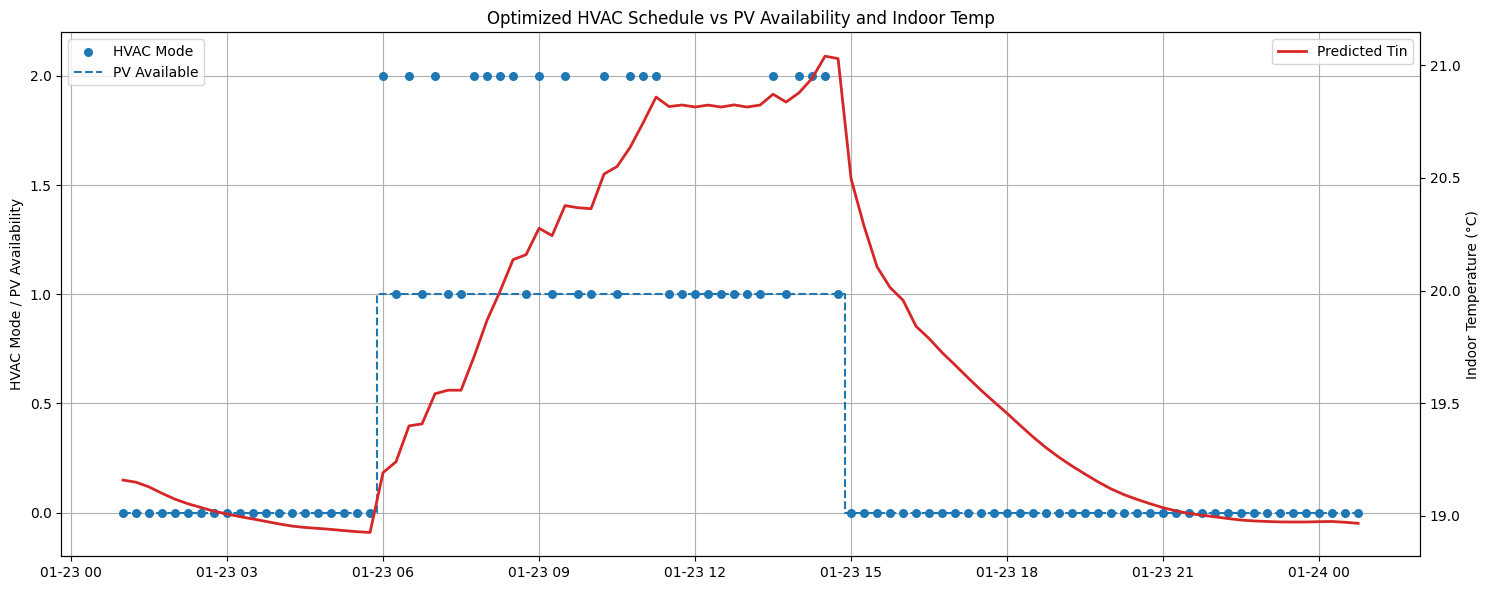

In [17]:
timestamps = pd.date_range(start=start_time, periods=96, freq='15T')
import matplotlib.pyplot as plt
# Create a DataFrame to plot
df_plot = pd.DataFrame({
    "timestamp": timestamps,
    "HVAC_mode": hvac_schedule,
    "PV_available": pv_forecast,
    "Tin_pred": Tin_pred
})
df_plot.set_index("timestamp", inplace=True)

# Plotting
fig, ax1 = plt.subplots(figsize=(15, 6))

# HVAC & PV (left Y-axis)
ax1.scatter(df_plot.index, df_plot["HVAC_mode"], label="HVAC Mode", color="tab:blue", s=30, zorder=3)
ax1.step(df_plot.index, df_plot["PV_available"], label="PV Available", where='mid', linestyle='--', linewidth=1.5)
ax1.set_ylabel("HVAC Mode / PV Availability")
ax1.set_ylim(-0.2, 2.2)
ax1.legend(loc="upper left")
ax1.grid(True)

# Temperature (right Y-axis)
ax2 = ax1.twinx()
ax2.plot(df_plot.index, df_plot["Tin_pred"], label="Predicted Tin", color="tab:red", linewidth=2)
ax2.set_ylabel("Indoor Temperature (°C)")
ax2.legend(loc="upper right")

# Title and X formatting
plt.title("Optimized HVAC Schedule vs PV Availability and Indoor Temp")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
print(ppd_list)

[np.float64(20.9), np.float64(21.0), np.float64(21.2), np.float64(21.4), np.float64(21.7), np.float64(21.8), np.float64(22.0), np.float64(22.2), np.float64(22.3), np.float64(22.4), np.float64(22.6), np.float64(22.7), np.float64(22.8), np.float64(22.9), np.float64(23.0), np.float64(23.1), np.float64(23.1), np.float64(23.2), np.float64(23.3), np.float64(23.4), np.float64(21.2), np.float64(20.8), np.float64(19.5), np.float64(19.4), np.float64(18.4), np.float64(18.2), np.float64(18.3), np.float64(17.2), np.float64(16.0), np.float64(15.1), np.float64(14.2), np.float64(14.1), np.float64(13.4), np.float64(13.6), np.float64(12.8), np.float64(12.8), np.float64(12.9), np.float64(12.1), np.float64(11.9), np.float64(11.4), np.float64(10.8), np.float64(10.3), np.float64(10.5), np.float64(10.5), np.float64(10.6), np.float64(10.6), np.float64(10.7), np.float64(10.7), np.float64(10.8), np.float64(10.8), np.float64(10.5), np.float64(10.6), np.float64(10.4), np.float64(10.0), np.float64(9.5), np.float64

In [29]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
from Hvac_predict_script import predict_next_step

class HVACEnv(gym.Env):
    def __init__(self, df_test, df_pv, window_start_idx, tin_model, rf_model, rh_model,
                 scaler_tin, scaler_rh, comfort_fn, forecast_fn):
        super(HVACEnv, self).__init__()

        self.df_test = df_test.copy()
        self.df_pv = df_pv.copy()
        self.start_idx = window_start_idx
        self.tin_model = tin_model
        self.rf_model = rf_model
        self.rh_model = rh_model
        self.scaler_tin = scaler_tin
        self.scaler_rh = scaler_rh
        self.forecast_fn = forecast_fn
        self.comfort_fn = comfort_fn

        self.time_steps = 96
        self.action_space = spaces.Discrete(3) 

        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, 0]),
            high=np.array([95, 1, 50, 100]),
            dtype=np.float32
        )

        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed) 
        self.current_step = 0
        self.schedule = []

        self.start_time = self.df_test.index[self.start_idx]
        self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")

        self.pv_forecast = (self.df_pv.loc[self.timestamps, "total_energy"] > 0.05).astype(int).tolist()

        self.Tin = [self.df_test.iloc[self.start_idx]["Tin"]] 
        self.RH = [self.df_test.iloc[self.start_idx]["RH"]]   

        return self._get_obs(), {}

    def _get_obs(self):
        t = min(self.current_step, self.time_steps - 1)
        obs = np.array([
            t,
            self.pv_forecast[t],
            self.Tin[-1],
            self.RH[-1]
        ], dtype=np.float32)
        return obs

    def step(self, action):
        self.schedule.append(action)
        self.current_step += 1

        # Forecast next Tin and RH from current schedule
        Tin_next, RH_next = predict_next_step(
            df_test=self.df_test,
            current_idx=self.start_idx + self.current_step,
            schedule=self.schedule,
            lstm_model=self.tin_model,
            rf_model=self.rf_model,
            tin_scaler=self.scaler_tin,
            rh_model=self.rh_model,
            rh_scaler=self.scaler_rh
        )

        self.Tin.append(Tin_next)
        self.RH.append(RH_next)

        comfort = 100 - self.comfort_fn([Tin_next], [RH_next])[0]  # PMV -> comfort %

        reward = 0
        if comfort >= 80:
            if self.pv_forecast[self.current_step - 1] and action > 0:
                reward += 1  # good: HVAC ON with PV
            elif action > 0:
                reward += 0.2  # acceptable: grid use for comfort
            else:
                reward -= 1  # discomfort risk due to HVAC off
        else:
            reward -= 3  # strong penalty for comfort violation

        terminated = self.current_step >= self.time_steps
        truncated = False
        info = {"comfort": comfort, "Tin": Tin_next, "RH": RH_next}
        return self._get_obs(), reward, terminated, truncated, info


In [30]:
pv_data['timestamps'] = pd.to_datetime(pv_data['timestamps'])  # ensure datetime type
pv_data.set_index('timestamps', inplace=True)

In [35]:
from stable_baselines3 import PPO

env = HVACEnv( 
    df_test=df_encoded_test,
    df_pv=pv_data,
    window_start_idx=100,  # or any index for the start of the 24h window
    tin_model=tin_model,
    rf_model=rf_model,
    rh_model=rh_model,
    scaler_tin=scaler_tin,
    scaler_rh=scaler_rh,
    comfort_fn=calculate_overall_comfort,  # function: returns ppd_list
    forecast_fn=predict_Tin_sequence_full  )

model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=100_000)

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")


Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 96       |
|    ep_rew_mean     | -112     |
| time/              |          |
|    fps             | 38       |
|    iterations      | 1        |
|    time_elapsed    | 52       |
|    total_timesteps | 2048     |
---------------------------------


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")


...

-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 96            |
|    ep_rew_mean          | 47.8          |
| time/                   |               |
|    fps                  | 30            |
|    iterations           | 47            |
|    time_elapsed         | 3190          |
|    total_timesteps      | 96256         |
| train/                  |               |
|    approx_kl            | 0.00019290298 |
|    clip_fraction        | 0.000879      |
|    clip_range           | 0.2           |
|    entropy_loss         | -0.00696      |
|    explained_variance   | 1             |
|    learning_rate        | 0.0003        |
|    loss                 | 0.00559       |
|    n_updates            | 460           |
|    policy_gradient_loss | -0.00052      |
|    value_loss           | 0.0584        |
-------------------------------------------


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")


-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 96            |
|    ep_rew_mean          | 47.8          |
| time/                   |               |
|    fps                  | 30            |
|    iterations           | 48            |
|    time_elapsed         | 3259          |
|    total_timesteps      | 98304         |
| train/                  |               |
|    approx_kl            | 0.00043856422 |
|    clip_fraction        | 0.00186       |
|    clip_range           | 0.2           |
|    entropy_loss         | -0.00465      |
|    explained_variance   | 0.999         |
|    learning_rate        | 0.0003        |
|    loss                 | 0.0101        |
|    n_updates            | 470           |
|    policy_gradient_loss | -0.000744     |
|    value_loss           | 0.101         |
-------------------------------------------


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2477133578.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  self.timestamps = pd.date_range(start=self.start_time, periods=96, freq="15T")


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 96           |
|    ep_rew_mean          | 47.8         |
| time/                   |              |
|    fps                  | 30           |
|    iterations           | 49           |
|    time_elapsed         | 3328         |
|    total_timesteps      | 100352       |
| train/                  |              |
|    approx_kl            | 0.0008223726 |
|    clip_fraction        | 0.00132      |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.00258     |
|    explained_variance   | 0.999        |
|    learning_rate        | 0.0003       |
|    loss                 | 0.0208       |
|    n_updates            | 480          |
|    policy_gradient_loss | -0.0011      |
|    value_loss           | 0.0985       |
------------------------------------------


In [ ]:
obs = env.reset()
done = False
while not done:
    action, _ = model.predict(obs)
    obs, reward, done, info = env.step(action)

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_8372\2336050300.py:4: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  time_axis = pd.date_range(start=env.df_test.index[env.start_idx], periods=n, freq="15T")


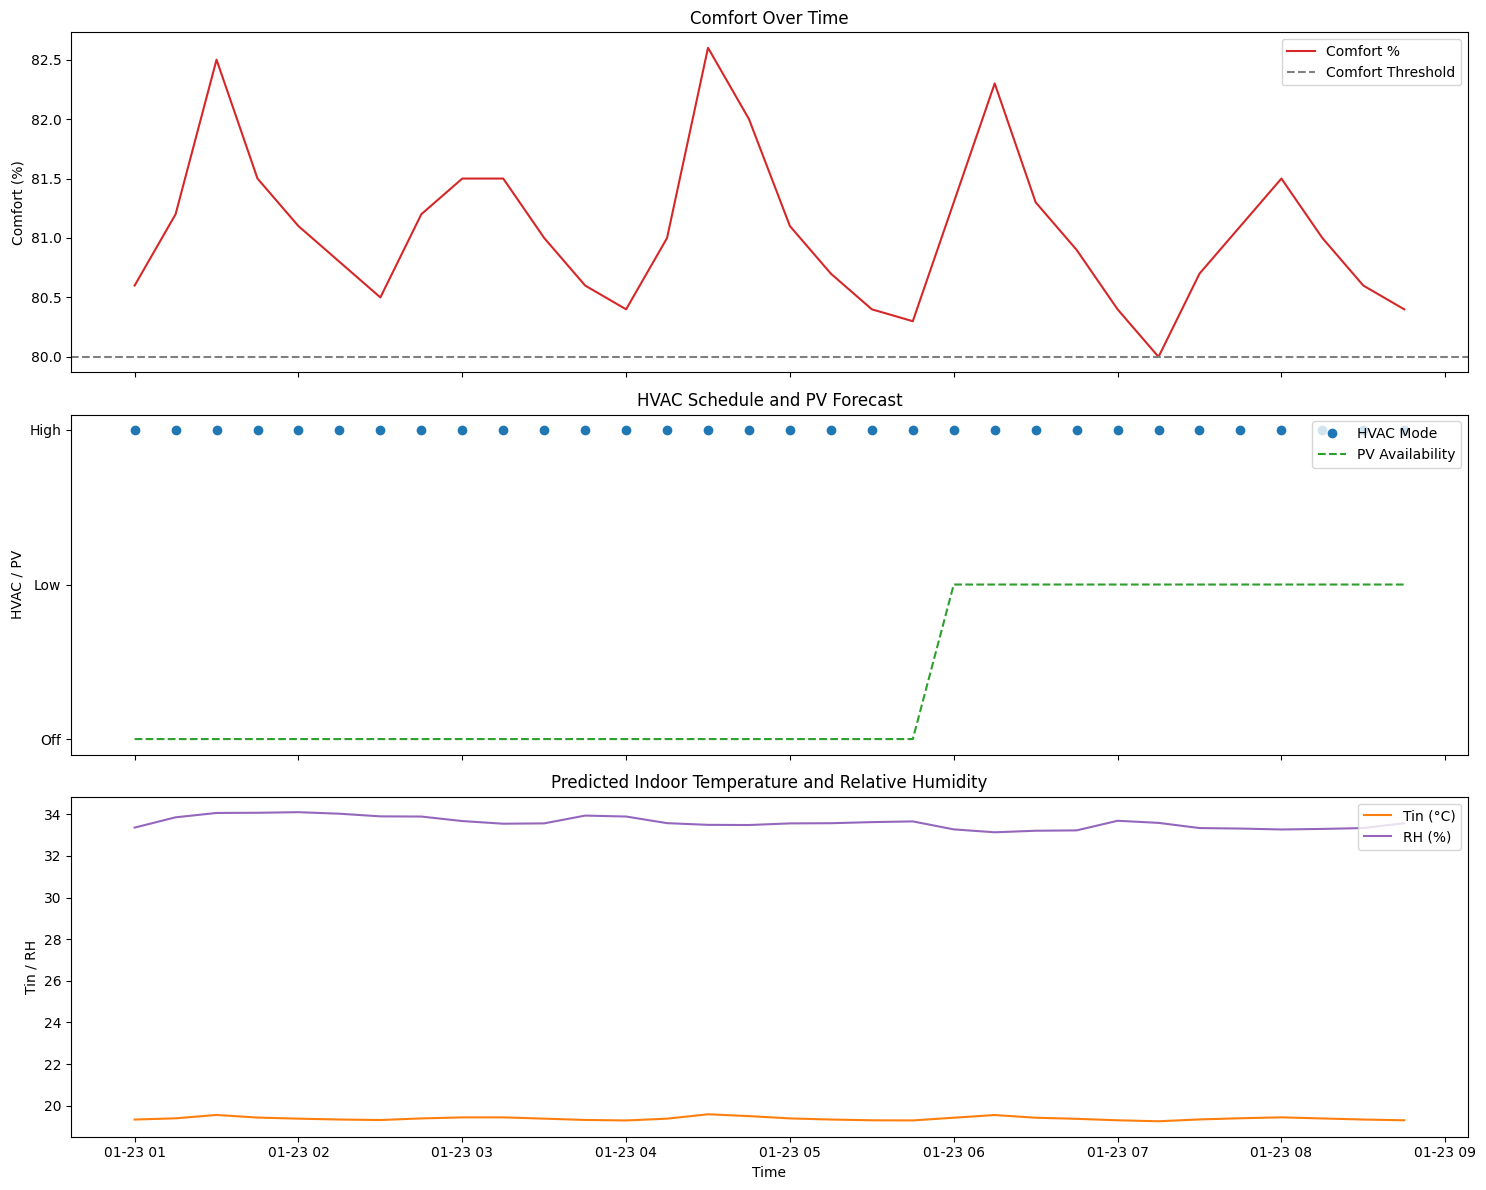

In [36]:
import matplotlib.pyplot as plt

n = len(env.schedule)
time_axis = pd.date_range(start=env.df_test.index[env.start_idx], periods=n, freq="15T")
comfort_list = [100 - c for c in calculate_overall_comfort(env.Tin[1:n+1], env.RH[1:n+1])]

fig, axs = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Comfort
axs[0].plot(time_axis, comfort_list, color='tab:red', label='Comfort %')
axs[0].axhline(80, linestyle="--", color="gray", label="Comfort Threshold")
axs[0].set_ylabel("Comfort (%)")
axs[0].legend(loc="upper right")
axs[0].set_title("Comfort Over Time")

# HVAC and PV
axs[1].plot(time_axis, env.schedule, label="HVAC Mode", color='tab:blue', marker='o', linestyle='None')
axs[1].plot(time_axis, env.pv_forecast[:n], label="PV Availability", color='tab:green', linestyle='--')
axs[1].set_ylabel("HVAC / PV")
axs[1].set_yticks([0, 1, 2])
axs[1].set_yticklabels(['Off', 'Low', 'High'])
axs[1].legend(loc="upper right")
axs[1].set_title("HVAC Schedule and PV Forecast")

# Tin & RH
axs[2].plot(time_axis, env.Tin[1:n+1], label="Tin (°C)", color='tab:orange')
axs[2].plot(time_axis, env.RH[1:n+1], label="RH (%)", color='tab:purple')
axs[2].set_ylabel("Tin / RH")
axs[2].legend(loc="upper right")
axs[2].set_title("Predicted Indoor Temperature and Relative Humidity")

plt.xlabel("Time")
plt.tight_layout()
plt.show()